Name: James Fisher
Date: April 12, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 7, Applied Question (AQ) 9

In [10]:
## Applied Question 9 in ISLR

# Load libraries
import pandas as pd
from ISLP import load_data
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load data from web (not available in ISLP package for Python)
url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/USArrests.csv"
USArrests = pd.read_csv(url, index_col=0)

print(USArrests.head())


            Murder  Assault  UrbanPop  Rape
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6


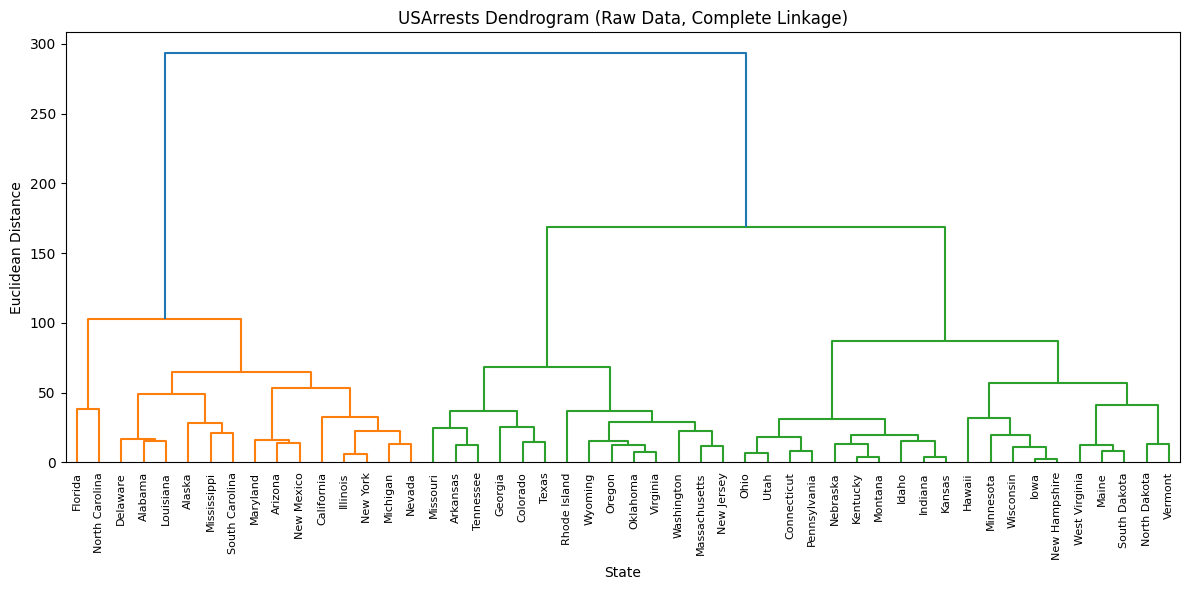

In [11]:
# Hierarchical clsutering (complete linkage + Euclidean distance)
Z_raw = linkage(USArrests, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z_raw, labels=USArrests.index.tolist(), leaf_rotation=90)
plt.title("USArrests Dendrogram (Raw Data, Complete Linkage)")
plt.xlabel("State")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

In [12]:
# Cut dendrogram to get 3 clusters
clusters_raw = fcluster(Z_raw, t=3, criterion="maxclust")

cluster_df_raw = pd.DataFrame({
    "State": USArrests.index,
    "Cluster": clusters_raw
}).sort_values(["Cluster", "State"])

print("\nCluster assignments for raw data (3 clusters):")
print(cluster_df_raw)

print("\nStates in each raw-data cluster:")
for k in sorted(cluster_df_raw["Cluster"].unique()):
    states_in_cluster = cluster_df_raw.loc[cluster_df_raw["Cluster"] == k, "State"].tolist()
    print(f"Cluster {k}:")
    print(states_in_cluster)
    print()



Cluster assignments for raw data (3 clusters):
             State  Cluster
0          Alabama        1
1           Alaska        1
2          Arizona        1
4       California        1
7         Delaware        1
8          Florida        1
12        Illinois        1
17       Louisiana        1
19        Maryland        1
21        Michigan        1
23     Mississippi        1
27          Nevada        1
30      New Mexico        1
31        New York        1
32  North Carolina        1
39  South Carolina        1
3         Arkansas        2
5         Colorado        2
9          Georgia        2
20   Massachusetts        2
24        Missouri        2
29      New Jersey        2
35        Oklahoma        2
36          Oregon        2
38    Rhode Island        2
41       Tennessee        2
42           Texas        2
45        Virginia        2
46      Washington        2
49         Wyoming        2
6      Connecticut        3
10          Hawaii        3
11           Idaho        3


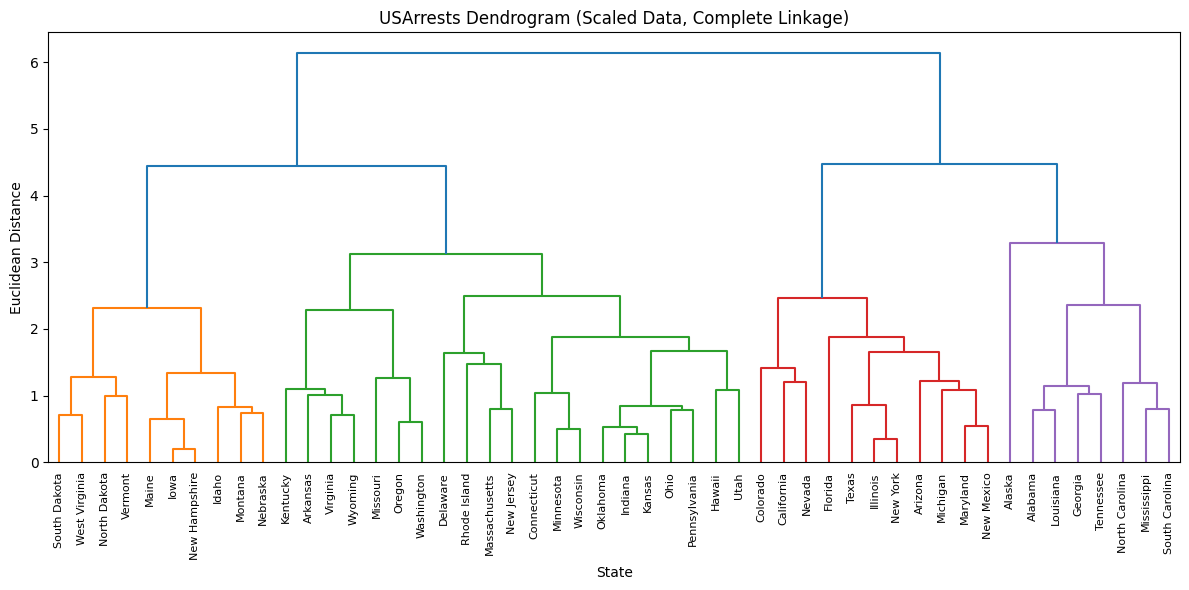


Cluster assignments for scaled data (3 clusters):
             State  Cluster
3         Arkansas        1
6      Connecticut        1
7         Delaware        1
10          Hawaii        1
11           Idaho        1
13         Indiana        1
14            Iowa        1
15          Kansas        1
16        Kentucky        1
18           Maine        1
20   Massachusetts        1
22       Minnesota        1
24        Missouri        1
25         Montana        1
26        Nebraska        1
28   New Hampshire        1
29      New Jersey        1
33    North Dakota        1
34            Ohio        1
35        Oklahoma        1
36          Oregon        1
37    Pennsylvania        1
38    Rhode Island        1
40    South Dakota        1
43            Utah        1
44         Vermont        1
45        Virginia        1
46      Washington        1
47   West Virginia        1
48       Wisconsin        1
49         Wyoming        1
2          Arizona        2
4       California       

In [15]:
# Hierarchical clustering after scaling
scaler = StandardScaler()
USArrests_scaled = scaler.fit_transform(USArrests)

Z_scaled = linkage(USArrests_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))

dendrogram(Z_scaled, labels=USArrests.index.tolist(), leaf_rotation=90)
plt.title("USArrests Dendrogram (Scaled Data, Complete Linkage)")
plt.xlabel("State")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

clusters_scaled = fcluster(Z_scaled, t=3, criterion="maxclust")

cluster_df_scaled = pd.DataFrame({
    "State": USArrests.index,
    "Cluster": clusters_scaled
}).sort_values(["Cluster", "State"])

print("\nCluster assignments for scaled data (3 clusters):")
print(cluster_df_scaled)

print("\nStates in each scaled-data cluster:")
for k in sorted(cluster_df_scaled["Cluster"].unique()):
    states_in_cluster = cluster_df_scaled.loc[cluster_df_scaled["Cluster"] == k, "State"].tolist()
    print(f"Cluster {k}:")
    print(states_in_cluster)
    print()
